<a href="https://colab.research.google.com/github/orsanchez2525/Herramientas_big_data/blob/master/V2_Modelo_Cancer_Prostata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#           Modelo Predictivo de Cáncer de Próstata
#                          Oscar Sanchez
#                 Proyecto de Machine Learning
#                    Famisanar EPS | 2026


In [24]:
import scipy.stats as stats

import polars as pl
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix,roc_curve,ConfusionMatrixDisplay, recall_score
from sklearn.pipeline import Pipeline

In [25]:
#from google.colab import drive
#drive.mount('/content/drive')

In [26]:
# Semilla para reproducibilidad
np.random.seed(1345)

# === 1. Cargar y preparar datos ===
#df_pd = pd.read_csv('/content/prostata_model.csv')
#df = pl.from_pandas(df_pd)

df = pl.read_csv('/content/prostata_model.csv')


#for col, dtype in zip(df.columns, df.dtypes):
#    print(col, "->", dtype)

target_col = "CON_DX_CANCER"

# Seleccionar solo columnas numéricas (excepto la de target)
numeric_cols = [
    col for col in df.columns
    if df[col].dtype in (pl.Float32, pl.Float64, pl.Int32, pl.Int64)
    and col != target_col
    and col.upper() not in [
        "ANTIGENO ESPECIFICO DE PROSTATA",
        "ANTIGENO ESPECIFICO DE PROSTATA, FRACCION LIBRE"
    ]
]
#print(numeric_cols)

# Convertir a pandas para usar sklearn
df_pandas = df.select(numeric_cols + [target_col]).to_pandas()

#Eliminar filas con valores faltantes en variables numéricas
df_pandas_clean = df_pandas.dropna(subset=numeric_cols)

# Definir X e y (aunque y no se usa ahora)
X = df_pandas_clean[numeric_cols].astype(np.float32)
y = df_pandas_clean[target_col]

# === 2. Escalado ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Aplicar PCA ===
pca = PCA(n_components=5)  # puedes ajustar el número de componentes
pca.fit(X_scaled)

# === 4. Obtener cargas de componentes ===
loadings = pd.DataFrame(
    np.abs(pca.components_.T),  # valor absoluto para medir contribución
    index=numeric_cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
# loadings

# === 5. Seleccionar variables más influyentes por componente ===
top_vars_per_pc = set()
n_top = 3  # cuántas variables tomar por componente

for pc in loadings.columns:
    top_vars = loadings[pc].nlargest(n_top).index.tolist()
    top_vars_per_pc.update(top_vars)
    print(pc,"-->",top_vars)

selected_variables = list(top_vars_per_pc)

print("Variables seleccionadas vía PCA:", selected_variables)

PC1 --> ['EDAD_CON_DIAGNOSTICO', 'MAX_POBL_EDAD', 'MAX_POBL_GRP_ETAREO']
PC2 --> ['F528', 'F528_pond', 'F529']
PC3 --> ['total_ponderado', 'N40X', 'N40X_pond']
PC4 --> ['R32X', 'R32X_pond', 'N394']
PC5 --> ['R31X', 'R31X_pond', 'R391']
Variables seleccionadas vía PCA: ['F528', 'MAX_POBL_EDAD', 'N394', 'R391', 'N40X', 'R31X', 'total_ponderado', 'F529', 'R32X', 'R31X_pond', 'F528_pond', 'R32X_pond', 'N40X_pond', 'EDAD_CON_DIAGNOSTICO', 'MAX_POBL_GRP_ETAREO']


In [27]:
variables_f =df[['CON_DX_CANCER','D65X','F528','R31X','N394','N40X','R31X_pond','D65X_pond','R32X_pond','EDAD_CON_DIAGNOSTICO','F528_pond','R32X','R33X','F529_pond','R390_pond','N40X_pond','PLAQUETAS', 'HGB']]

In [28]:
variables_f = variables_f.with_columns([
    pl.col("PLAQUETAS").str.strip_chars('"').cast(pl.Float64, strict=False),
    pl.col("HGB").str.strip_chars('"').cast(pl.Float64, strict=False)
])

In [29]:
display(variables_f.limit(10))

CON_DX_CANCER,D65X,F528,R31X,N394,N40X,R31X_pond,D65X_pond,R32X_pond,EDAD_CON_DIAGNOSTICO,F528_pond,R32X,R33X,F529_pond,R390_pond,N40X_pond,PLAQUETAS,HGB
i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,i64,i64,f64,f64,f64,f64,f64
0,0,0,0,0,1,0.0,0.0,0.0,64,0.0,0,0,0.0,0.0,0.639633,0.0,0.0
0,0,0,0,0,1,0.0,0.0,0.068688,50,0.0,1,1,0.0,0.0,0.639633,425.0,17.1
0,0,0,0,0,1,0.0,0.0,0.0,75,0.0,0,0,0.0,0.0,0.639633,222.0,14.6
0,0,0,0,0,1,0.0,0.0,0.0,57,0.0,0,0,0.0,0.0,0.639633,254.0,18.6
0,0,0,0,0,1,0.0,0.0,0.0,47,0.0,0,0,0.0,0.0,0.639633,0.0,0.0
0,0,0,0,0,1,0.0,0.0,0.0,57,0.0,0,0,0.0,0.0,0.639633,0.0,0.0
0,0,0,0,0,1,0.0,0.0,0.0,65,0.0,0,0,0.0,0.0,0.639633,280.0,16.4
1,0,0,0,0,0,0.0,0.0,0.0,58,0.0,0,0,0.0,0.0,0.0,254.0,16.4
0,0,0,0,0,1,0.0,0.0,0.0,57,0.0,0,0,0.0,0.0,0.639633,0.0,0.0


# Regresión Logísitica con Plaquetas y HGB depurado

In [37]:
# Simulación de datos (sustituir por tu DataFrame)

target_col = "CON_DX_CANCER"

#X_variables= ['F529', 'R32X', 'D65X', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R31X', 'R33X','F528', 'R390','PLAQUETAS', 'HGB']
X_variables= ['D65X', 'F528', 'R31X', 'N394', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R32X', 'R33X','PLAQUETAS', 'HGB']

variables_f =  variables_f.drop_nulls()
variables_f = variables_f.filter((pl.col("PLAQUETAS") != 0) & (pl.col("HGB") != 0))

df_pandas = variables_f.to_pandas()
X = df_pandas[X_variables]
y = df_pandas[target_col]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear el modelo de regresión logística
logreg = LogisticRegression(solver="liblinear")

# Crear un pipeline con escalado y modelo
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # Normalización de las características
    ("logreg", logreg)
])

# Ajustar el modelo a los datos de entrenamiento
pipeline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Evaluar el modelo con métricas de clasificación
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])  # AUC-ROC

# Evaluar el modelo con métricas de clasificación
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])  # AUC-ROC

# Mostrar métricas de evaluación
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("AUC-ROC:", roc_auc)

# Matriz de confusión
#conf_matrix = confusion_matrix(y_test, y_pred)
#print("\nMatriz de confusión:")
#print(conf_matrix)


# ← AGREGA ESTO AQUÍ
resultados["Logistic Regression"] = {"Recall": recall, "F1 Score": f1, "Accuracy": accuracy, "AUC-ROC": roc_auc}

Recall: 0.7471620227038184
F1 Score: 0.7797522886375875
Accuracy: 0.9284777476610999
AUC-ROC: 0.9082007546066171


#Modelo Adamboost con Plaquetas y HGB depurado

In [38]:
# === 1. Configuración de columnas y datos ===
target_col = "CON_DX_CANCER"

X_variables= ['D65X', 'F528', 'R31X', 'N394', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R32X', 'R33X','PLAQUETAS', 'HGB']

variables_f =  variables_f.drop_nulls()
variables_f = variables_f.filter((pl.col("PLAQUETAS") != 0) & (pl.col("HGB") != 0))

df_pandas = variables_f.to_pandas()
X = df_pandas[X_variables]
y = df_pandas[target_col]

# === 2. División del dataset ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# === 3. Modelo AdaBoost ===
adaboost = AdaBoostClassifier(n_estimators= 100, random_state=42)

# === 4. Pipeline con escalador y modelo ===
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # Escalado de variables
    ("adaboost", adaboost)         # Clasificador
])

# === 5. Entrenamiento del modelo ===
pipeline.fit(X_train, y_train)

# === 6. Predicciones y evaluación ===
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo con métricas de clasificación
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])  # AUC-ROC

# Mostrar métricas de evaluación
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("AUC-ROC:", roc_auc)

# === 8. Matriz de confusión ===
#conf_matrix = confusion_matrix(y_test, y_pred)
#print("\nMatriz de confusión:")
#print(conf_matrix)

resultados["AdaBoost"] = {"Recall": recall, "F1 Score": f1, "Accuracy": accuracy, "AUC-ROC": roc_auc}

Recall: 0.718266253869969
F1 Score: 0.7536545749864645
Accuracy: 0.9204336801608813
AUC-ROC: 0.8992658072421071


# Modelo XGBoosting con Plaquetas y HGB depurado

In [46]:
# === 1. Preparar datos ===
target_col = "CON_DX_CANCER"

X_variables= ['D65X', 'F528', 'R31X', 'N394', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R32X', 'R33X','PLAQUETAS', 'HGB']

variables_f =  variables_f.drop_nulls()
variables_f = variables_f.filter((pl.col("PLAQUETAS") != 0) & (pl.col("HGB") != 0))

df_pandas = variables_f.to_pandas()
X = df_pandas[X_variables]
y = df_pandas[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# === 2. Pipeline con escalado y XGBoost ===
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# === 3. GridSearch para maximizar recall ===
param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__scale_pos_weight": [5, 7, 10]  # importante si hay desbalance
}

grid_xgb  = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

# === 4. Predicciones con umbral del 50% ===
y_proba = grid_xgb.predict_proba(X_test)[:, 1]
threshold = 0.50
y_pred = (y_proba >= threshold).astype(int)

# === 5. Métricas ===
print("🏁 Mejor configuración encontrada:", grid_xgb.best_params_)
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))


resultados["XGBoost"] = {"Recall": recall_score(y_test, y_pred), "F1 Score": f1_score(y_test, y_pred), "Accuracy": accuracy_score(y_test, y_pred), "AUC-ROC": roc_auc_score(y_test, y_proba)}



Fitting 5 folds for each of 36 candidates, totalling 180 fits
🏁 Mejor configuración encontrada: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__scale_pos_weight': 10}
Recall: 0.8343653250773994
F1 Score: 0.698488120950324
Accuracy: 0.8779400192358136
AUC-ROC: 0.9148751305199581


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:00:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Modelo LightGBM con Plaquetas y HGB depurado

In [40]:
# === 1. Preparar datos ===
target_col = "CON_DX_CANCER"

X_variables= ['D65X', 'F528', 'R31X', 'N394', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R32X', 'R33X','PLAQUETAS', 'HGB']

variables_f =  variables_f.drop_nulls()
variables_f = variables_f.filter((pl.col("PLAQUETAS") != 0) & (pl.col("HGB") != 0))

df_pandas = variables_f.to_pandas()
X = df_pandas[X_variables]
y = df_pandas[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# === 2. Pipeline con escalado y LightGBM ===
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lgbm", LGBMClassifier(random_state=42))
])

# === 3. GridSearch para maximizar recall ===
param_grid = {
    "lgbm__n_estimators": [100, 200],
    "lgbm__max_depth": [3, 5, 7],
    "lgbm__learning_rate": [0.05, 0.1],
    "lgbm__class_weight": [None, 'balanced']  # manejo de desbalance
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# === 4. Predicciones ===
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

# === 5. Métricas ===
print("🏁 Mejor configuración encontrada:", grid.best_params_)
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))


resultados["LightGBM"] = {"Recall": recall_score(y_test, y_pred), "F1 Score": f1_score(y_test, y_pred), "Accuracy": accuracy_score(y_test, y_pred), "AUC-ROC": roc_auc_score(y_test, y_proba)}



Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Number of positive: 4388, number of negative: 22296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 26684, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Modelo RandomForest con Plaquetas y HGB depurado

In [41]:
target_col = "CON_DX_CANCER"

X_variables= ['D65X', 'F528', 'R31X', 'N394', 'N40X', 'EDAD_CON_DIAGNOSTICO', 'R32X', 'R33X','PLAQUETAS', 'HGB']

variables_f =  variables_f.drop_nulls()
variables_f = variables_f.filter((pl.col("PLAQUETAS") != 0) & (pl.col("HGB") != 0))

df_pandas = variables_f.to_pandas()
X = df_pandas[X_variables]
y = df_pandas[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# === 2. Pipeline con escalado y Random Forest ===
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

# === 3. GridSearch para maximizar recall ===
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 10, None],
    "rf__class_weight": [None, 'balanced']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# === 4. Predicciones ===
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

# === 5. Métricas ===
print("🏁 Mejor configuración encontrada:", grid.best_params_)
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))


resultados["Random Forest"] = {"Recall": recall_score(y_test, y_pred), "F1 Score": f1_score(y_test, y_pred), "Accuracy": accuracy_score(y_test, y_pred), "AUC-ROC": roc_auc_score(y_test, y_proba)}


Fitting 5 folds for each of 12 candidates, totalling 60 fits
🏁 Mejor configuración encontrada: {'rf__class_weight': 'balanced', 'rf__max_depth': 5, 'rf__n_estimators': 100}
Recall: 0.8163054695562435
F1 Score: 0.7356428737502906
Accuracy: 0.9005858179592551
AUC-ROC: 0.9102614788303717


In [42]:
df_resultados = pd.DataFrame(resultados).T.round(4)
df_styled = df_resultados.style \
    .highlight_max(axis=0, color="lightgreen") \
    .highlight_min(axis=0, color="#ffcccc") \
    .set_caption("Comparación de Modelos — Verde: mejor | Rojo: peor") \
    .format("{:.4f}")
display(df_styled)
mejor_modelo = df_resultados["Recall"].idxmax()
print(f"\n🏆 Mejor modelo por Recall: {mejor_modelo} ({df_resultados.loc[mejor_modelo, 'Recall']:.4f})")

,Recall,F1 Score,Accuracy,AUC-ROC
Logistic Regression,0.7472,0.7798,0.9285,0.9082
AdaBoost,0.7183,0.7537,0.9204,0.8993
XGBoost,0.8344,0.6985,0.8779,0.9149
LightGBM,0.8127,0.7440,0.9052,0.9146
Random Forest,0.8163,0.7356,0.9006,0.9103



🏆 Mejor modelo por Recall: XGBoost (0.8344)


In [52]:

df_cod = pl.read_csv('/content/V1_codigos.csv', separator=";")
df_nue = pl.read_csv('/content/prostata_model.csv')


In [56]:
# Crea un diccionario {codigo: nombre}
dict_codigos = dict(zip(df_cod["Codigo"].to_list(), df_cod["Variable"].to_list()))
print(dict_codigos)
# → {"D65X": "COAGULACION INTRAVASCULAR...", "N40X": "HIPERPLASIA DE PROSTATA", ...}

{'D65X': 'COAGULACION INTRAVASCULAR DISEMINADA [SINDROME DE DESFIBRINACION]', 'F520': 'FALTA O PERDIDA DEL DESEO SEXUAL', 'F522': 'FALLA DE LA RESPUESTA GENITAL', 'F528': 'OTRAS DISFUNCIONES SEXUALES NO OCASIONADAS POR TRASTORNO NI POR ENFERMEDAD ORGANICOS', 'F529': 'DISFUNCION SEXUAL NO OCASIONADA POR TRASTORNO NI POR ENFERMEDAD ORGANICOS NO ESPECIFICADA', 'N328': 'OTROS TRASTORNOS ESPECIFICADOS DE LA VEJIGA', 'N394': 'OTRAS INCONTINENCIAS URINARIAS ESPECIFICADAS', 'N40X': 'HIPERPLASIA DE LA PROSTATA', 'R300': 'DISURIA', 'R309': 'MICCION DOLOROSA NO ESPECIFICADA', 'R31X': 'HEMATURIA NO ESPECIFICADA', 'R32X': 'INCONTINENCIA URINARIA NO ESPECIFICADA', 'R33X': 'RETENCION DE ORINA', 'R35X': 'POLIURIA', 'R390': 'EXTRAVASACION DE LA ORINA', 'R391': 'OTRAS DIFICULTADES DE LA MICCION', 'S302': 'CONTUSION DE LOS ORGANOS GENITALES EXTERNOS'}


In [57]:
# Reemplaza cada código por su nombre, si no está en el diccionario deja el código
X_variables_nombres = [dict_codigos.get(col, col) for col in X_variables]
print(X_variables_nombres)

['COAGULACION INTRAVASCULAR DISEMINADA [SINDROME DE DESFIBRINACION]', 'OTRAS DISFUNCIONES SEXUALES NO OCASIONADAS POR TRASTORNO NI POR ENFERMEDAD ORGANICOS', 'HEMATURIA NO ESPECIFICADA', 'OTRAS INCONTINENCIAS URINARIAS ESPECIFICADAS', 'HIPERPLASIA DE LA PROSTATA', 'EDAD_CON_DIAGNOSTICO', 'INCONTINENCIA URINARIA NO ESPECIFICADA', 'RETENCION DE ORINA', 'PLAQUETAS', 'HGB']


Variables con nombres:
  COAGULACION INTRAVASCULAR DISEMINADA [SINDROME DE DESFIBRINACION] -- D65X
  OTRAS DISFUNCIONES SEXUALES NO OCASIONADAS POR TRASTORNO NI POR ENFERMEDAD ORGANICOS -- F528
  HEMATURIA NO ESPECIFICADA -- R31X
  OTRAS INCONTINENCIAS URINARIAS ESPECIFICADAS -- N394
  HIPERPLASIA DE LA PROSTATA -- N40X
  EDAD_CON_DIAGNOSTICO
  INCONTINENCIA URINARIA NO ESPECIFICADA -- R32X
  RETENCION DE ORINA -- R33X
  PLAQUETAS
  HGB

📊 Importancia promedio de variables (SHAP)


/tmp/ipykernel_11667/198272523.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_11667/198272523.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


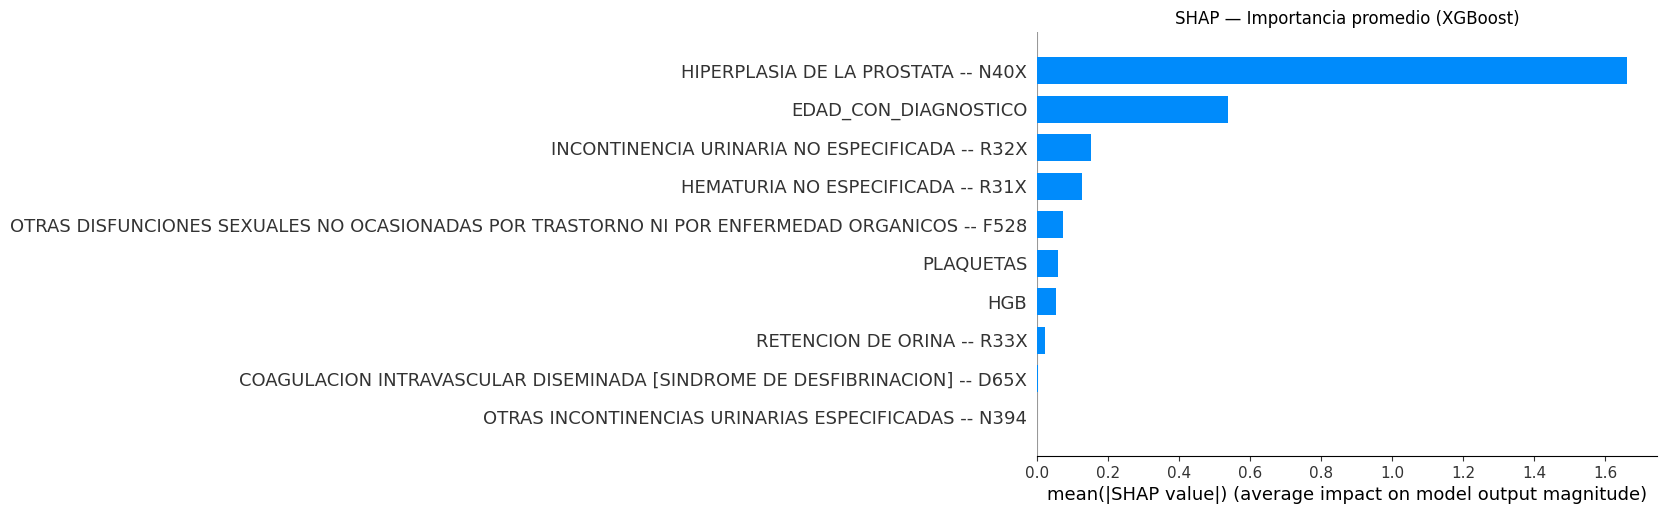


📊 Distribución de impacto por variable (Beeswarm)


/tmp/ipykernel_11667/198272523.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_11667/198272523.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


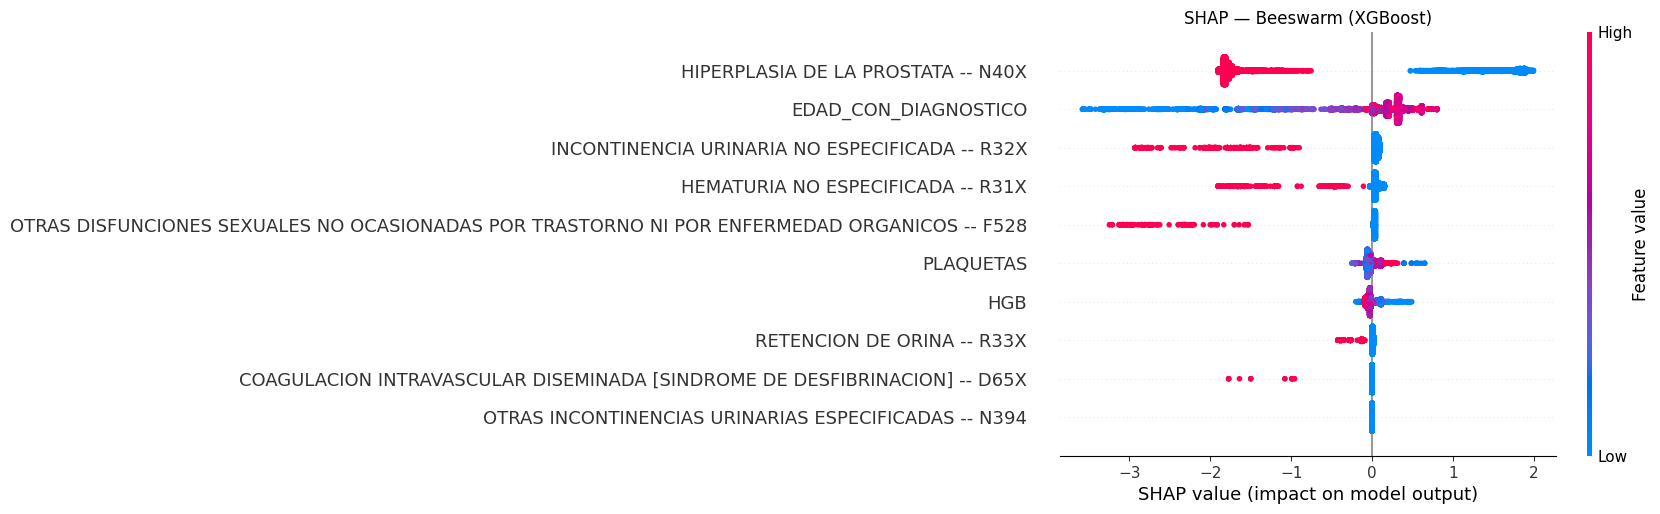


📊 Explicación individual — Paciente 1


 93%|=================== | 10643/11437 [00:14<00:01]       

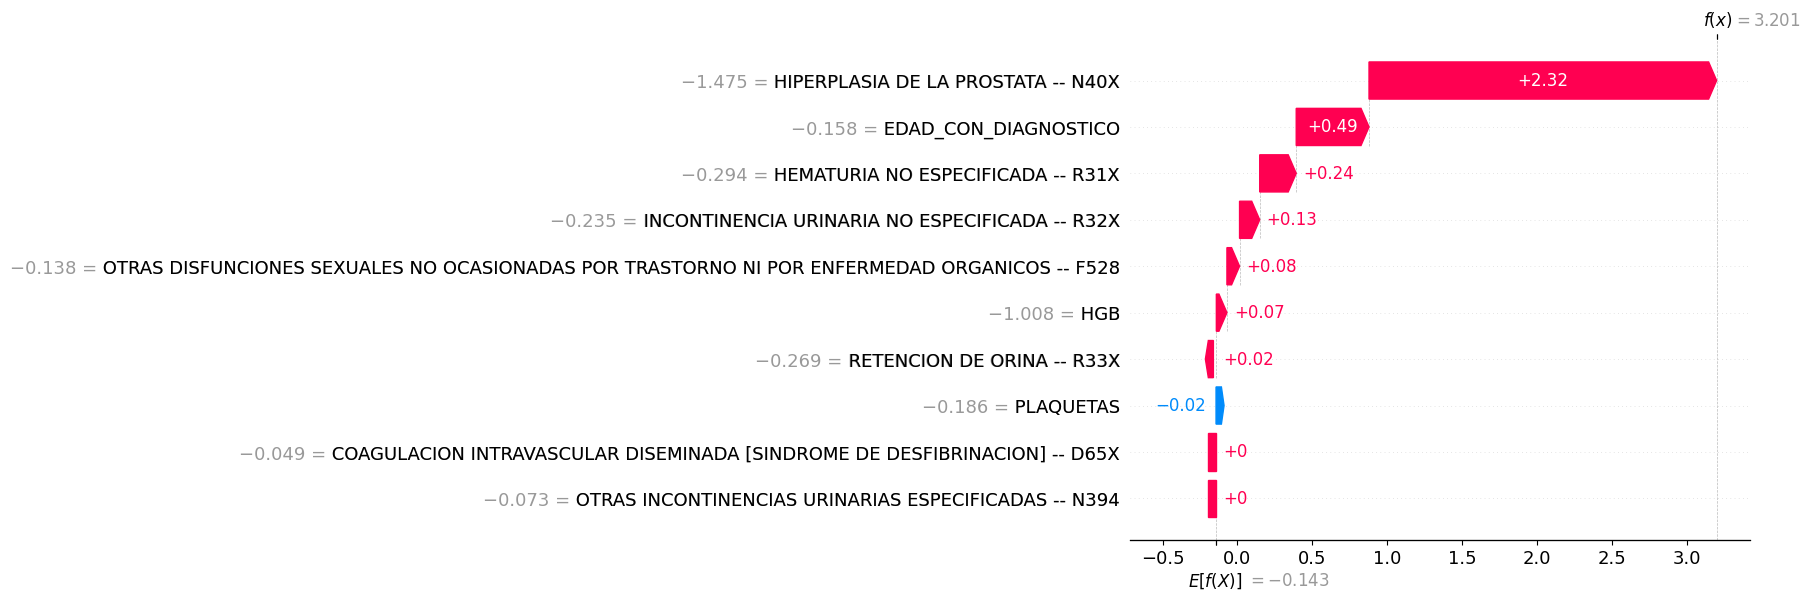

In [60]:
import shap
import matplotlib.pyplot as plt

# === 1. Diccionario de códigos ===
dict_codigos = dict(zip(df_cod["Codigo"].to_list(), df_cod["Variable"].to_list()))

# === 2. Lista de nombres "NOMBRE -- CODIGO" ===
X_variables_nombres = [
    f"{dict_codigos.get(col, col)} -- {col}" if col in dict_codigos else col
    for col in X_variables
]
print("Variables con nombres:")
for v in X_variables_nombres:
    print(" ", v)

# === 3. Extraer modelo y scaler del pipeline XGBoost ===
best_pipeline = grid_xgb.best_estimator_
best_model    = best_pipeline.named_steps["xgb"]
scaler_shap   = best_pipeline.named_steps["scaler"]

# === 4. Escalar X_test ===
X_test_scaled = scaler_shap.transform(X_test)

# === 5. TreeExplainer ===
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# === 6. Bar plot — importancia promedio ===
print("\n📊 Importancia promedio de variables (SHAP)")
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables_nombres,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importancia promedio (XGBoost)")
plt.tight_layout()
plt.show()

# === 7. Beeswarm — distribución de impacto ===
print("\n📊 Distribución de impacto por variable (Beeswarm)")
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables_nombres,
    show=False
)
plt.title("SHAP — Beeswarm (XGBoost)")
plt.tight_layout()
plt.show()

# === 8. Waterfall — explicación primer paciente ===
print("\n📊 Explicación individual — Paciente 1")
explainer2   = shap.Explainer(best_model, X_test_scaled, feature_names=X_variables_nombres)
shap_values2 = explainer2(X_test_scaled)
shap.plots.waterfall(shap_values2[0])
plt.show()

/tmp/ipykernel_11667/4266812456.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_11667/4266812456.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


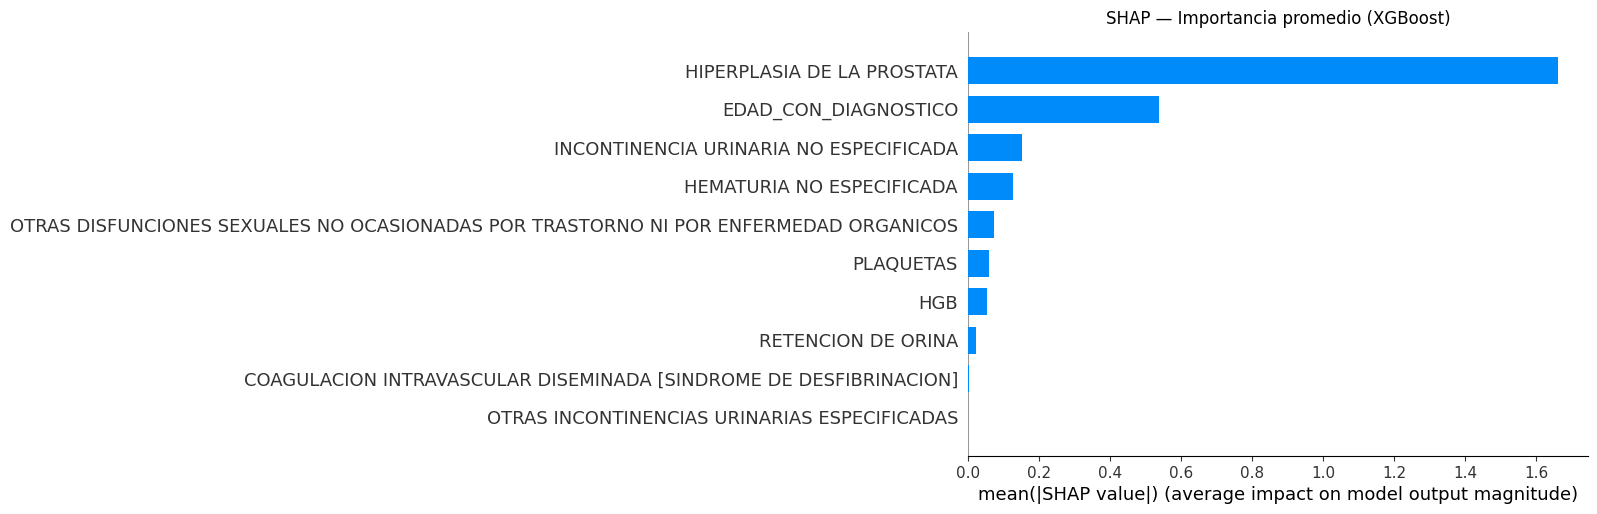

/tmp/ipykernel_11667/4266812456.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_11667/4266812456.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


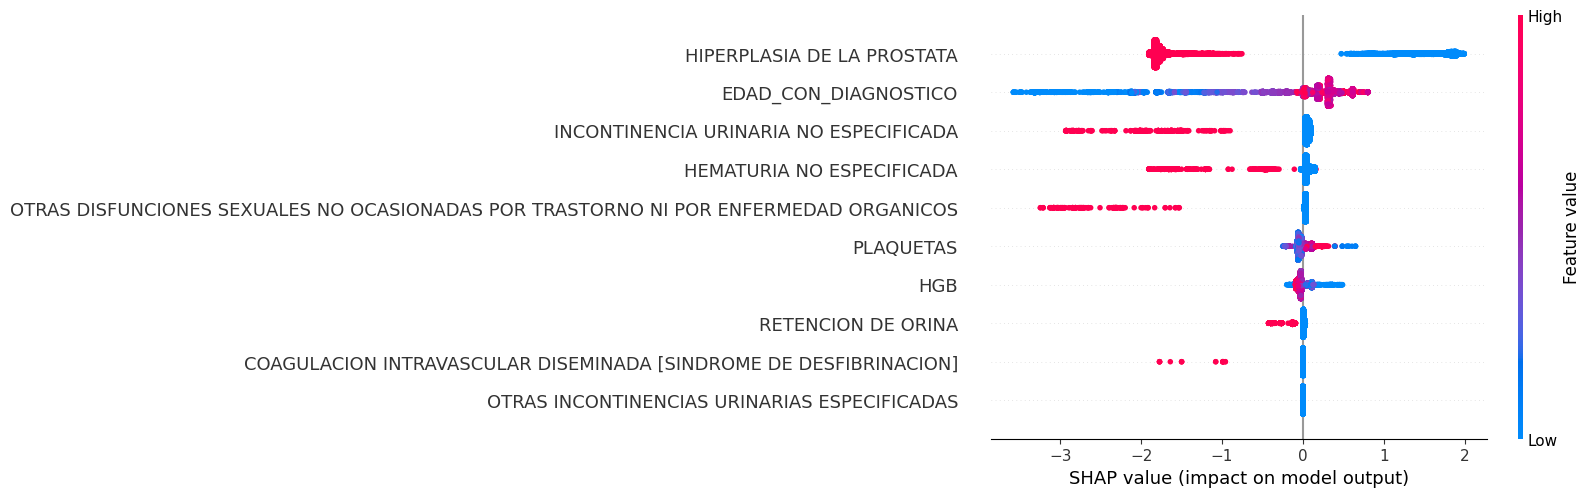

 93%|=================== | 10614/11437 [00:14<00:01]       

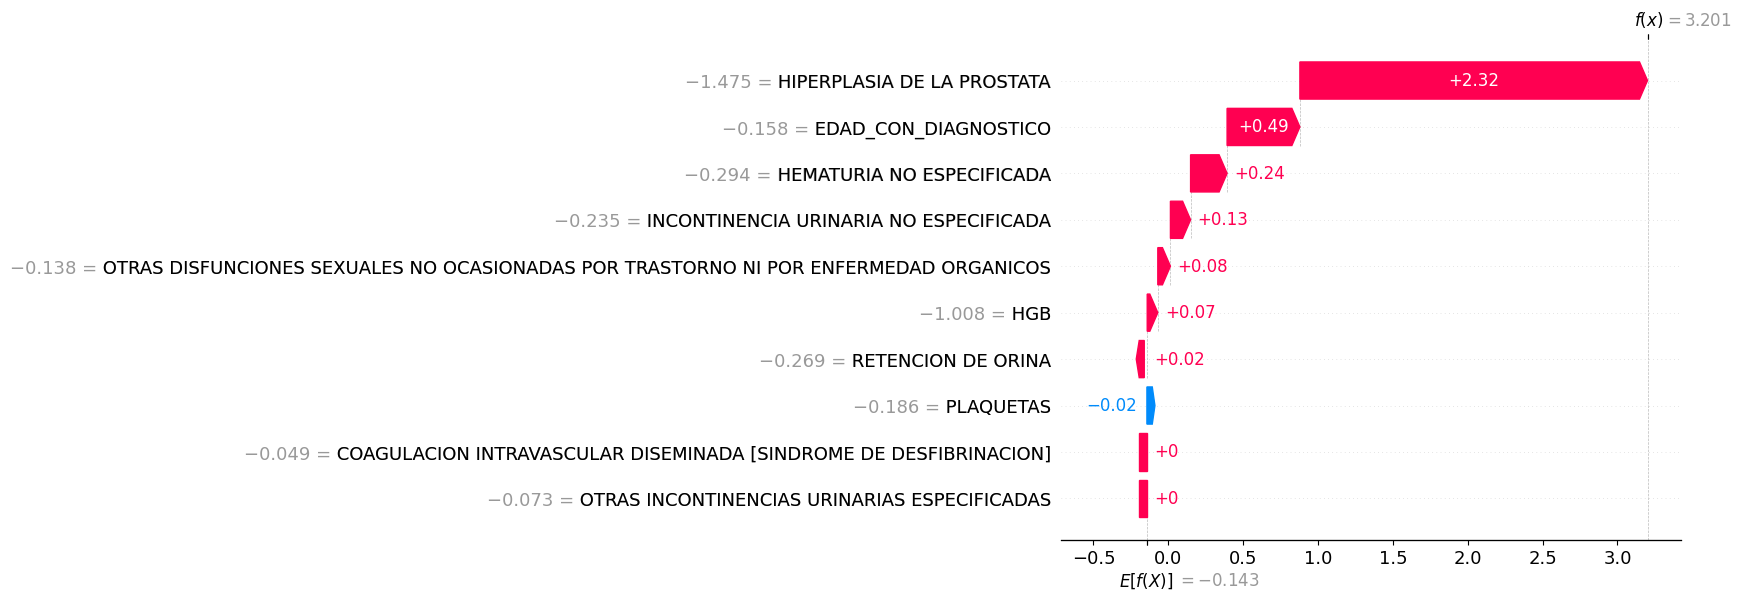

In [58]:
# Bar plot con nombres
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables_nombres,   # ← cambia aquí
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importancia promedio (XGBoost)")
plt.tight_layout()
plt.show()

# Beeswarm con nombres
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables_nombres,   # ← cambia aquí
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall con nombres
explainer2   = shap.Explainer(best_model, X_test_scaled, feature_names=X_variables_nombres)  # ← cambia aquí
shap_values2 = explainer2(X_test_scaled)
shap.plots.waterfall(shap_values2[0])
plt.show()

📊 Importancia promedio de variables (SHAP)


/tmp/ipykernel_11667/1449442732.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


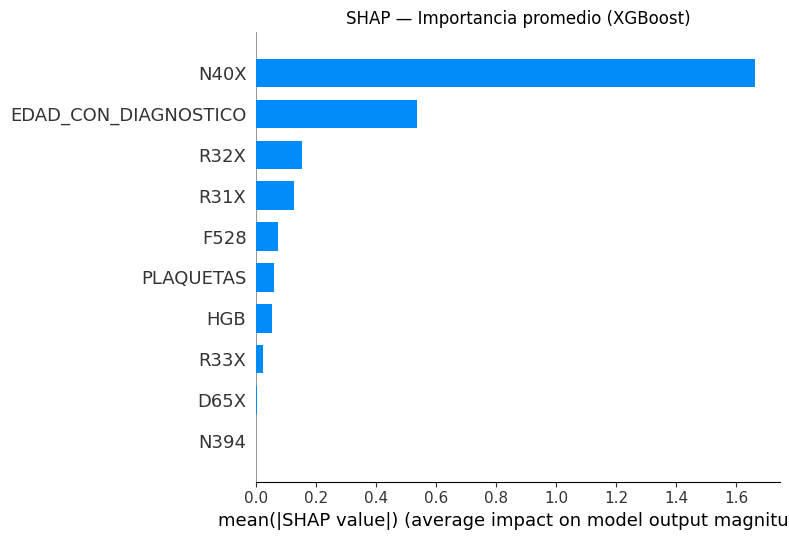

📊 Distribución de impacto por variable (Beeswarm)


/tmp/ipykernel_11667/1449442732.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


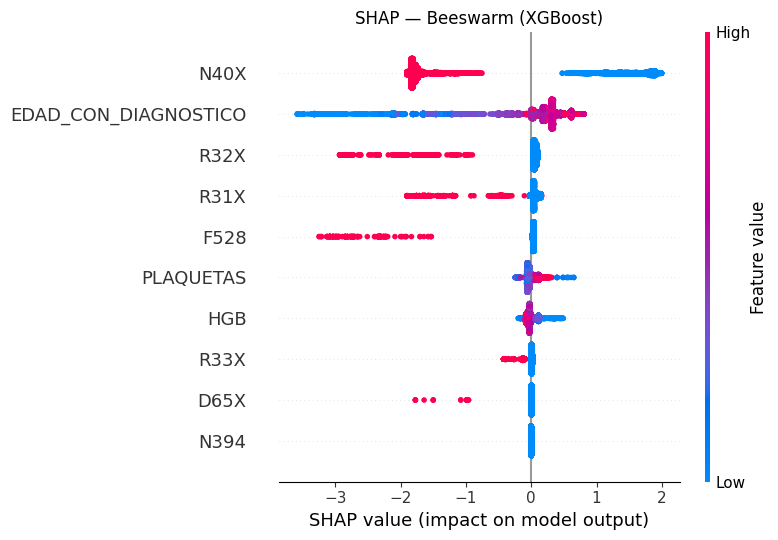

📊 Explicación individual — Paciente 1


 95%|=================== | 10859/11437 [00:16<00:00]       

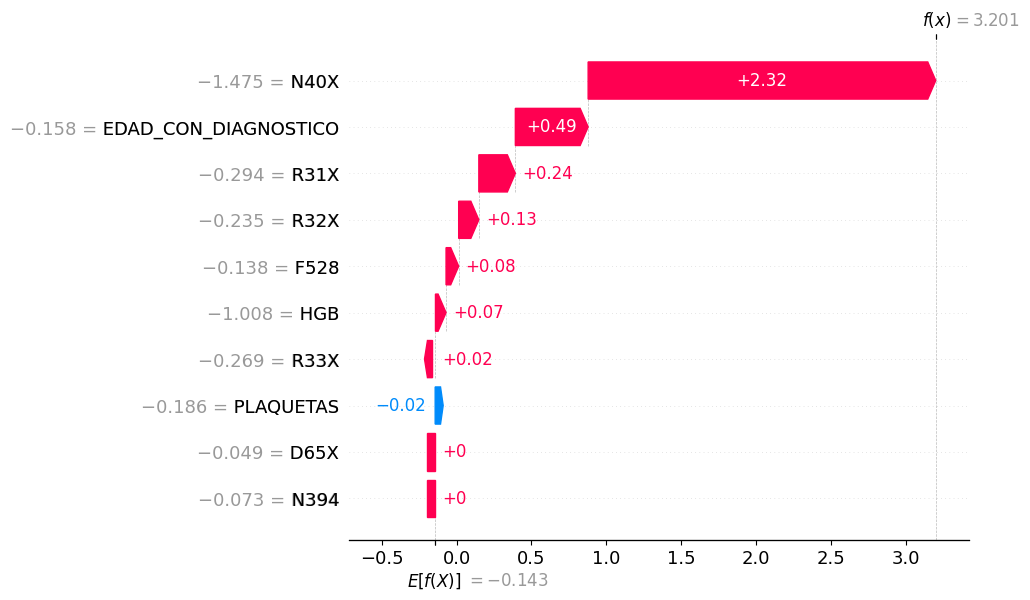

In [59]:
import shap
import matplotlib.pyplot as plt

# === SHAP para XGBoost ===
# Extraer modelo y scaler del pipeline de XGBoost
best_pipeline = grid_xgb.best_estimator_
best_model    = best_pipeline.named_steps["xgb"]
scaler_shap   = best_pipeline.named_steps["scaler"]

# Escalar X_test con el scaler del pipeline XGBoost
X_test_scaled = scaler_shap.transform(X_test)

# === 1. TreeExplainer (correcto para XGBoost) ===
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# === 2. Bar plot — importancia promedio por variable ===
print("📊 Importancia promedio de variables (SHAP)")
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importancia promedio (XGBoost)")
plt.tight_layout()
plt.show()

# === 3. Beeswarm — distribución de impacto por variable ===
print("📊 Distribución de impacto por variable (Beeswarm)")
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_variables,
    show=False
)
plt.title("SHAP — Beeswarm (XGBoost)")
plt.tight_layout()
plt.show()

# === 4. Waterfall — explicación del primer paciente ===
print("📊 Explicación individual — Paciente 1")
explainer2   = shap.Explainer(best_model, X_test_scaled, feature_names=X_variables)
shap_values2 = explainer2(X_test_scaled)
shap.plots.waterfall(shap_values2[0])
plt.show()